In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve
import shap

# ==================== LOAD THE DATA ====================
# If you unzipped the file:
df = pd.read_csv('data/TCGA-BRCA.star_fpkm-uq.tsv', sep='\t', index_col=0)

# OR if you kept the .gz file (no need to unzip):
# df = pd.read_csv('data/TCGA-BRCA.star_fpkm-uq.tsv.gz', sep='\t', index_col=0, compression='gzip')

print(f"Original shape (genes × samples): {df.shape}")
print(df.head())

# Transpose so each row = one sample (standard for ML)
df = df.T
print(f"After transpose (samples × genes): {df.shape}")

Original shape (genes × samples): (60660, 1226)
                    TCGA-D8-A146-01A  TCGA-AQ-A0Y5-01A  TCGA-C8-A274-01A  \
Ensembl_ID                                                                 
ENSG00000000003.15          3.767708          2.132741          4.768010   
ENSG00000000005.6           1.759454          0.146003          0.000000   
ENSG00000000419.13          4.920541          5.284151          5.051694   
ENSG00000000457.14          2.612588          2.428544          3.356299   
ENSG00000000460.17          1.363395          1.158337          2.458172   

                    TCGA-BH-A0BD-01A  TCGA-B6-A1KC-01B  TCGA-AC-A62V-01A  \
Ensembl_ID                                                                 
ENSG00000000003.15          3.049735          3.009311          2.262163   
ENSG00000000005.6           1.071763          0.185993          0.308594   
ENSG00000000419.13          4.618797          4.852973          5.364065   
ENSG00000000457.14          2.680774   

Sample distribution:
sample_type
Tumor     1106
Normal     120
Name: count, dtype: int64


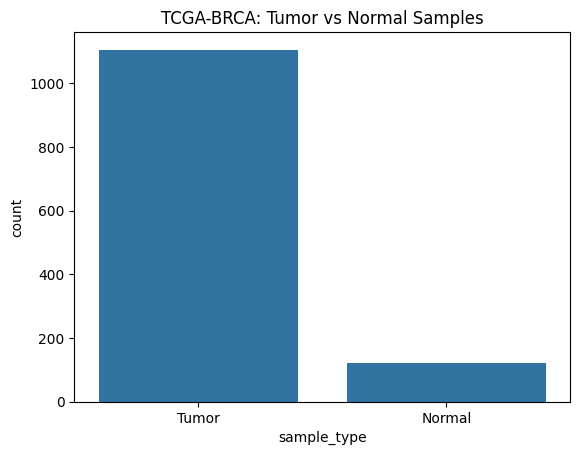

Selected top 5000 genes. New feature matrix shape: (1226, 5000)
✅ Data ready for modeling!
Final X shape: (1226, 5000) | y shape: (1226,)


In [6]:
# ==================== CREATE LABELS ====================
# TCGA barcode logic: 4th part (e.g. 01A = Tumor, 11A = Normal)
df['sample_type'] = df.index.map(
    lambda x: 'Tumor' if x.split('-')[3].startswith('01') else 'Normal'
)

print("Sample distribution:")
print(df['sample_type'].value_counts())

# Quick plot
sns.countplot(data=df, x='sample_type')
plt.title('TCGA-BRCA: Tumor vs Normal Samples')
plt.show()

# ==================== PREPROCESSING ====================
# 1. Features only (drop label column)
X = df.drop('sample_type', axis=1)

# 2. Feature selection: keep top 5000 genes with highest variance
variances = X.var(axis=0)
top_genes = variances.nlargest(5000).index
X = X[top_genes]

print(f"Selected top 5000 genes. New feature matrix shape: {X.shape}")

# 3. Scale the data
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 4. Labels as 0/1
y = df['sample_type'].map({'Tumor': 1, 'Normal': 0})

print(f"Final X shape: {X_scaled.shape} | y shape: {y.shape}")

In [7]:
print(f"X shape: {X_scaled.shape} | y shape: {y.shape}")

✅ Data already prepared!
X shape: (1226, 5000) | y shape: (1226,)


In [9]:
np.save('X_scaled.npy', X_scaled)
y.to_csv('y_labels.csv', index=False)
pd.Series(top_genes).to_csv('top_genes.csv', index=False)

In [17]:
# ==================== LOAD THE PREPROCESSED DATA ====================
print(f"X shape: {X_scaled.shape} | y shape: {y.shape}")

X shape: (1226, 5000) | y shape: (1226,)


In [18]:
# ==================== TRAIN-TEST SPLIT ====================
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples: {X_train.shape[0]} | Test samples: {X_test.shape[0]}")

Training samples: 980 | Test samples: 246


In [19]:
# ==================== MODEL 1: Random Forest ====================
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_prob_rf = rf.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("RANDOM FOREST RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_rf):.4f}")
print(classification_report(y_test, y_pred_rf))


RANDOM FOREST RESULTS
Accuracy: 0.9837
ROC-AUC: 0.9981
              precision    recall  f1-score   support

           0       0.95      0.88      0.91        24
           1       0.99      1.00      0.99       222

    accuracy                           0.98       246
   macro avg       0.97      0.94      0.95       246
weighted avg       0.98      0.98      0.98       246



In [20]:
# ==================== MODEL 2: XGBoost (usually the best) ====================
xgb = XGBClassifier(n_estimators=300, learning_rate=0.1, max_depth=6, random_state=42, n_jobs=-1)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
y_pred_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("\n" + "="*50)
print("XGBOOST RESULTS")
print("="*50)
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred_prob_xgb):.4f}")
print(classification_report(y_test, y_pred_xgb))


XGBOOST RESULTS
Accuracy: 0.9959
ROC-AUC: 0.9992
              precision    recall  f1-score   support

           0       0.96      1.00      0.98        24
           1       1.00      1.00      1.00       222

    accuracy                           1.00       246
   macro avg       0.98      1.00      0.99       246
weighted avg       1.00      1.00      1.00       246



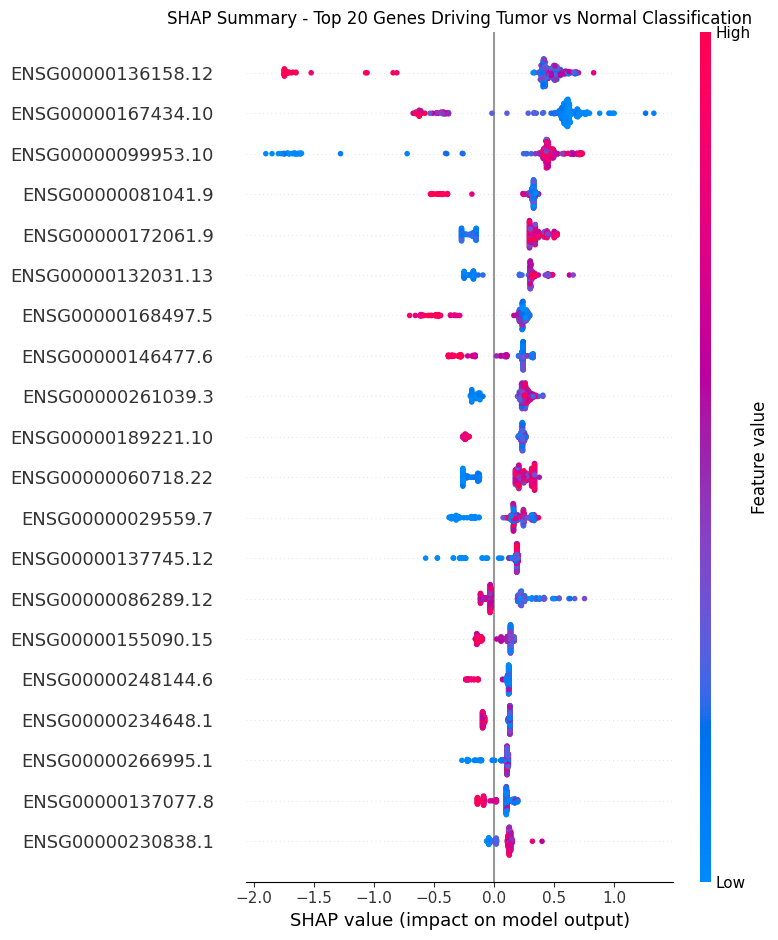

In [21]:
# ==================== SHAP EXPLAINABILITY (the wow factor) ====================
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test[:300])   # using 300 samples for speed

# SHAP Summary Plot
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test[:300], feature_names=X.columns, max_display=20, show=False)
plt.title("SHAP Summary - Top 20 Genes Driving Tumor vs Normal Classification")
plt.tight_layout()
plt.savefig("shap_summary.png", dpi=300, bbox_inches='tight')
plt.show()

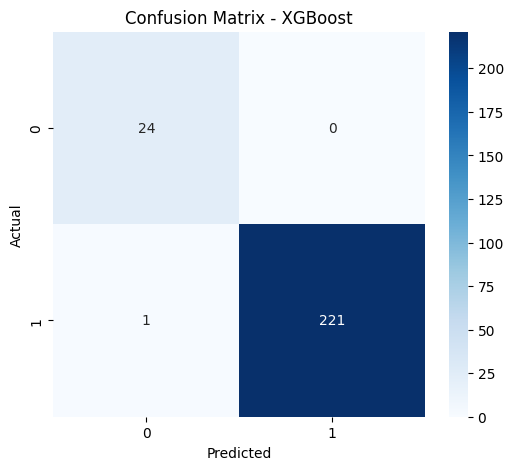

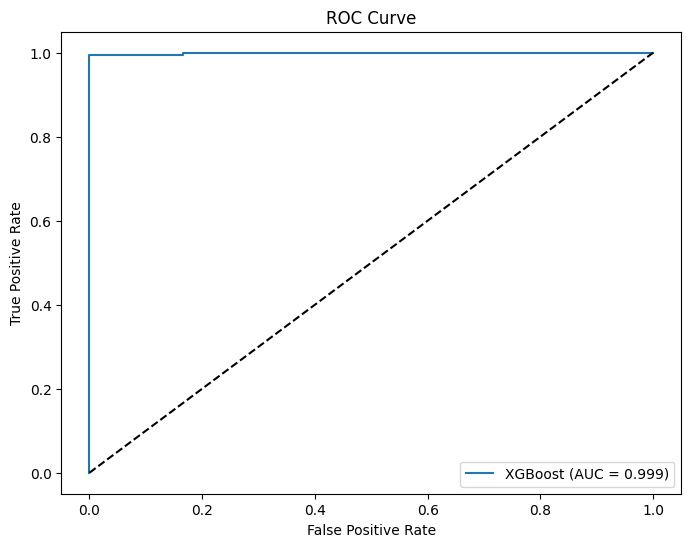

In [22]:
# ==================== EXTRA VISUALIZATIONS ====================

# 1. Confusion Matrix (XGBoost)
cm = confusion_matrix(y_test, y_pred_xgb)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig("confusion_matrix.png", dpi=300)
plt.show()

# 2. ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_xgb)
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_pred_prob_xgb):.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.savefig("roc_curve.png", dpi=300)
plt.show()